<a href="https://colab.research.google.com/github/priyanshibangia08/Titanic-project/blob/main/TitanicProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kaggle - Titanic - Machine Learning from Disaster

The Titanic dataset is one of the most popular datasets used in machine learning for binary classification problems. The task is to predict which passengers survived the Titanic disaster based on various features. I’ll guide you through the steps of Exploratory Data Analysis (EDA), modeling, evaluation, and submission for the Titanic problem.

Let's break the solution into three main parts:

1. Exploratory Data Analysis (EDA) & Feature Engineering
2. Modeling and Evaluation
3. Submitting Predictions on Kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! pip install pandas matplotlib seaborn scikit-learn xgboost

## EDA
Kaggle provides the Titanic dataset for training and testing. You can download the dataset from [Kaggle Titanic Competition](https://www.kaggle.com/competitions/titanic/data).

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#train_path = 'C:\Users\HP\Downloads\KAGGLE DATASETS\train.csv'
#test_path = 'C:\Users\HP\Downloads\KAGGLE DATASETS\test.csv'

# Load train and test data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Inspect the data
print(train.head())
print(train.info())
print(train.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

### Missing Values

In [ ]:
train.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


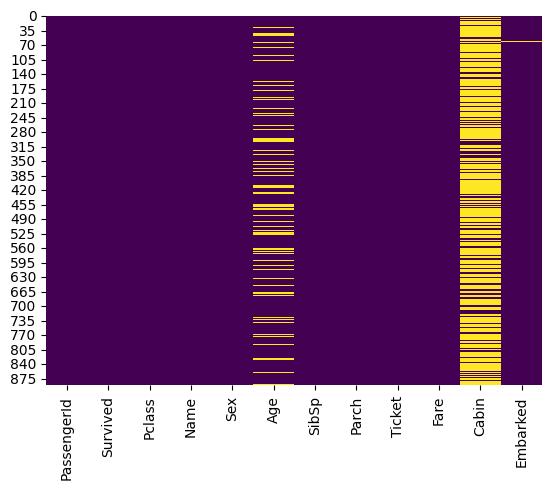

In [ ]:
# Check for missing values
print(train.isna().sum())

# Visualize missing values
sns.heatmap(train.isna(), cbar=False, cmap='viridis')
plt.show()

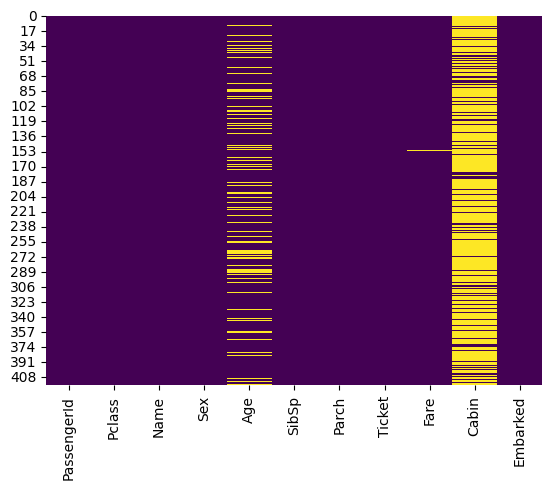

In [ ]:
# Visualize missing values
sns.heatmap(test.isna(), cbar=False, cmap='viridis')
plt.show()

### Visualize Relationships

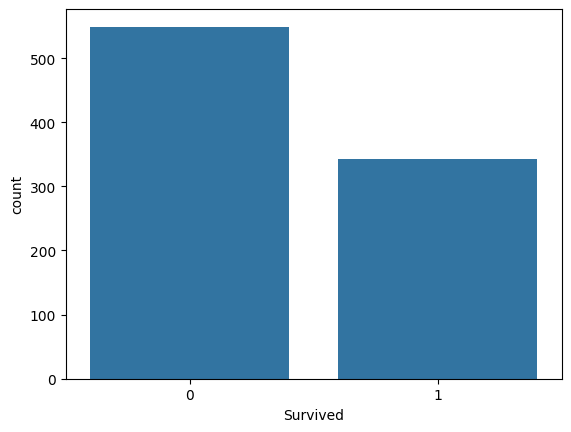

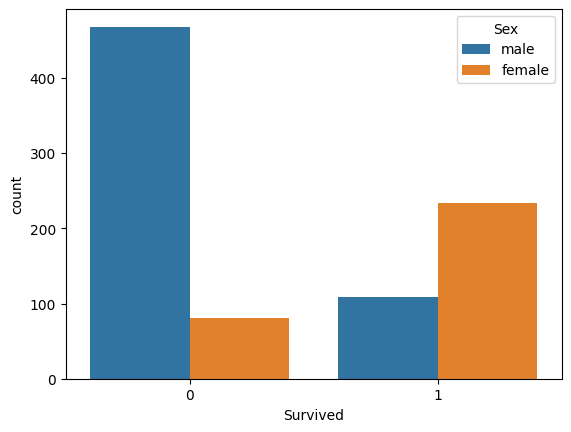

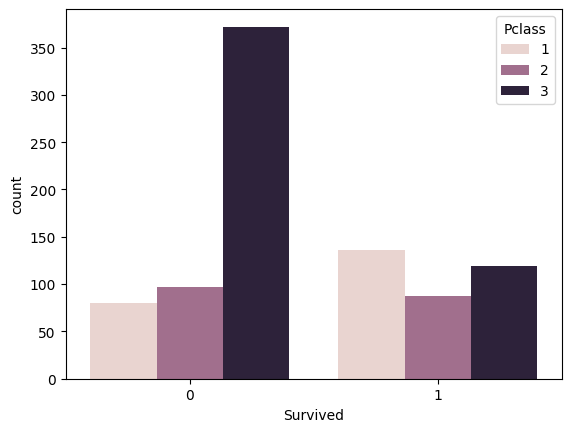

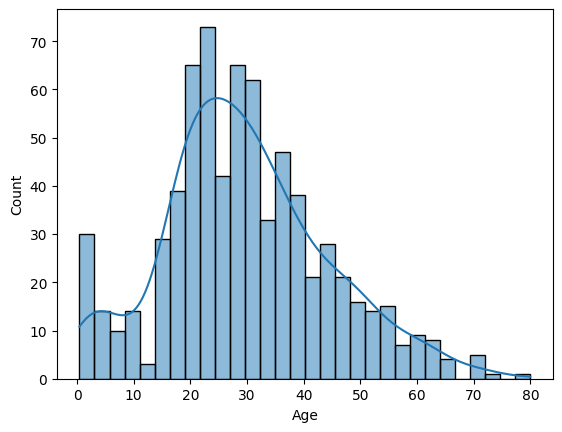

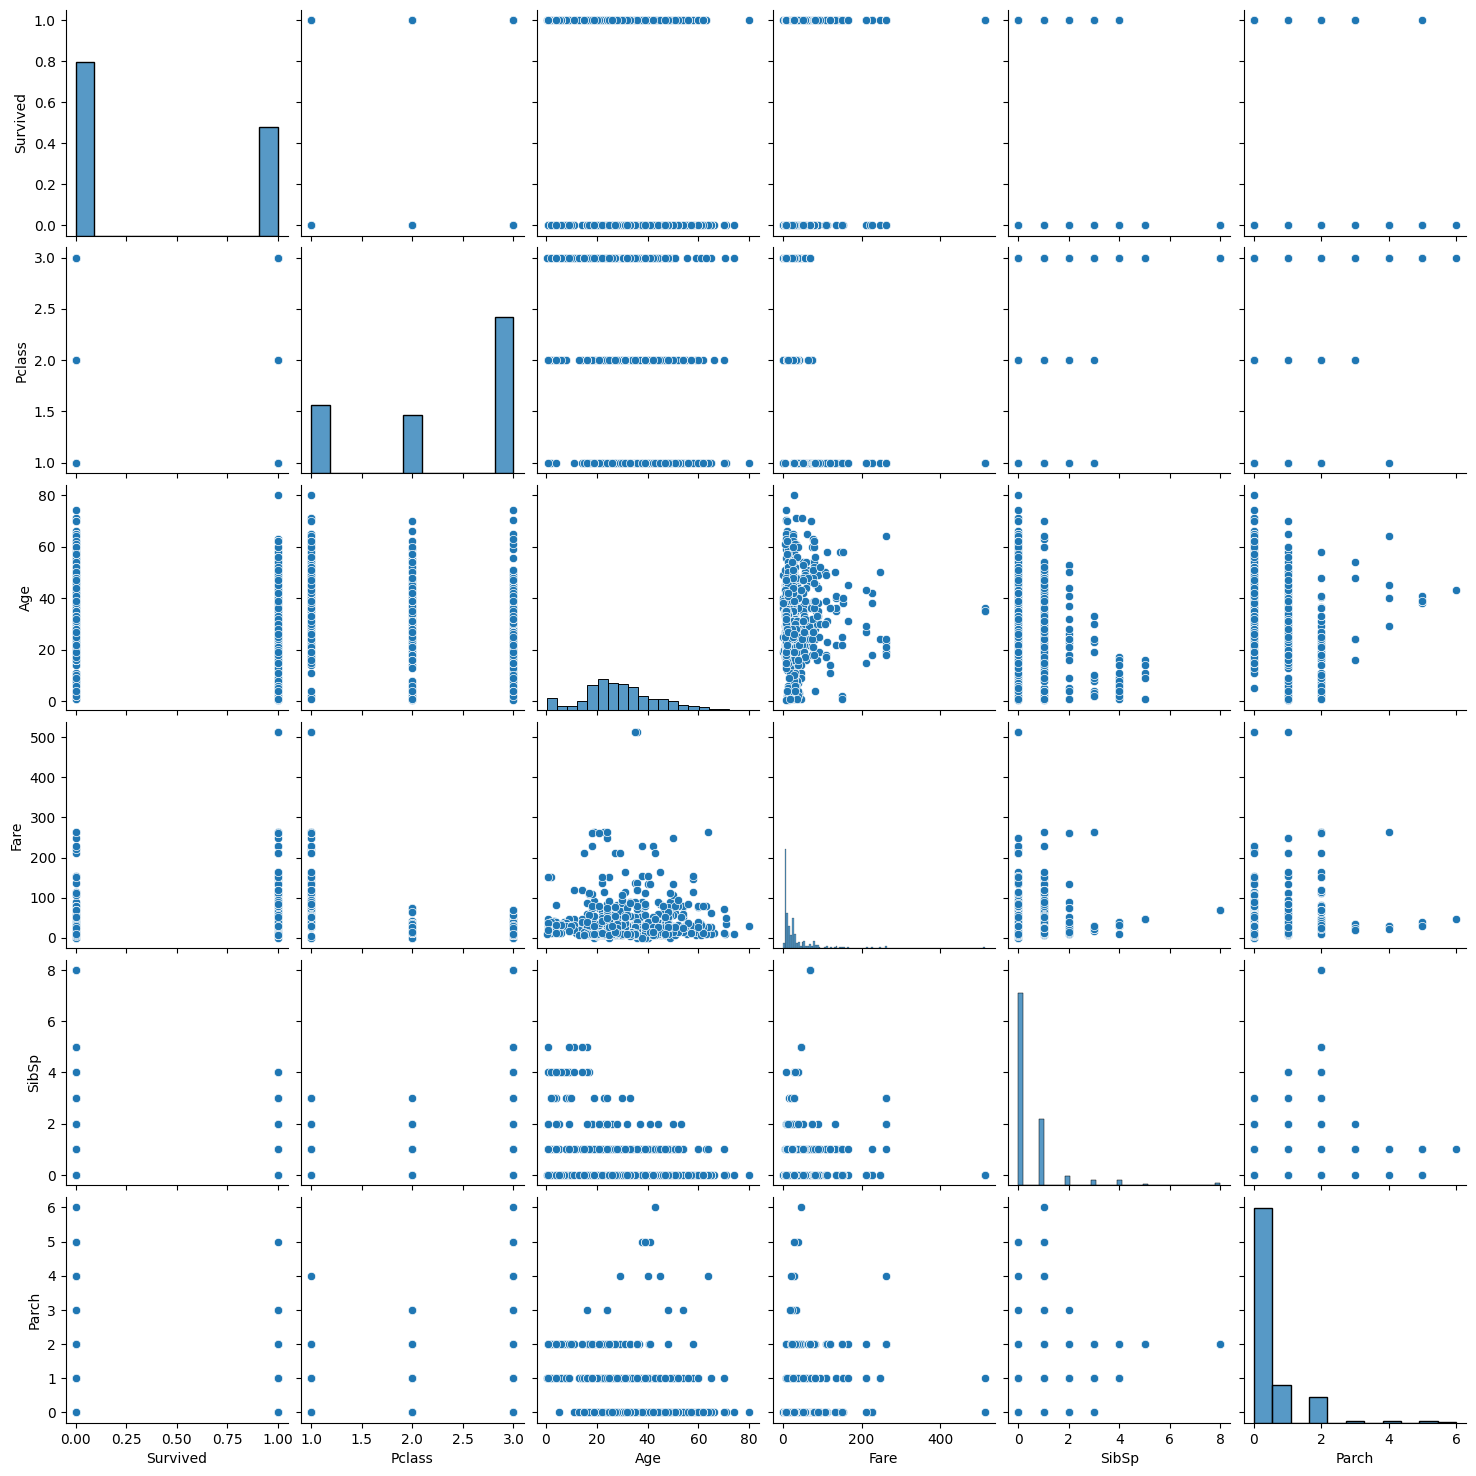

In [ ]:
# Survived vs Not Survived
sns.countplot(data=train, x='Survived')
plt.show()

# Survival rate by Sex
sns.countplot(data=train, x='Survived', hue='Sex')
plt.show()

# Survival rate by Passenger Class
sns.countplot(data=train, x='Survived', hue='Pclass')
plt.show()

# Age distribution
sns.histplot(train['Age'].dropna(), bins=30, kde=True)
plt.show()

# Pairplot to see relations between numeric features
sns.pairplot(train[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']])
plt.show()

## Feature Engineering

### Handle Missing Data

In [ ]:
# Fill missing 'Age' values with the median age
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

# Fill missing 'Embarked' values with the mode (most frequent value)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin' as it has too many missing values
train.drop(columns='Cabin', inplace=True)
test.drop(columns='Cabin', inplace=True)

/tmp/ipython-input-1946444989.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
/tmp/ipython-input-1946444989.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

### Encoding Categorical Variables

In [ ]:
# Convert 'Sex' to numerical values
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

# One-hot encode 'Embarked'
train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)

### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Apply StandardScaler to 'Age' and 'Fare'
scaler = StandardScaler()

train[['Age', 'Fare']] = scaler.fit_transform(train[['Age', 'Fare']])
test[['Age', 'Fare']] = scaler.transform(test[['Age', 'Fare']])

## Modeling and Evaluation

### Split Columns

In [ ]:
# Define features (drop columns that aren't needed)
X = train.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket'])
y = train['Survived']

# Define test features (similarly dropping unused columns)
X_test = test.drop(columns=['PassengerId', 'Name', 'Ticket'])

### Train-Test Split for Evaluation

In [ ]:
from sklearn.model_selection import train_test_split

# Split data for training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Train the Model (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10000, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the validation set
y_pred = rf_model.predict(X_val)

# Evaluate the model
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred)}")
print(f"Confusion Matrix:\n {confusion_matrix(y_val, y_pred)}")
print(f"Classification Report:\n {classification_report(y_val, y_pred)}")

Validation Accuracy: 0.8156424581005587
Confusion Matrix:
 [[90 15]
 [18 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



### Hyperparameter Tuning (optional)

In [ ]:
from sklearn.model_selection import GridSearchCV
# Define hyperparameters to search
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
# Initialize GridSearchCV
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='accuracy')
# Fit the grid search
grid_search.fit(X_train, y_train)
# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

Best parameters: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 300}


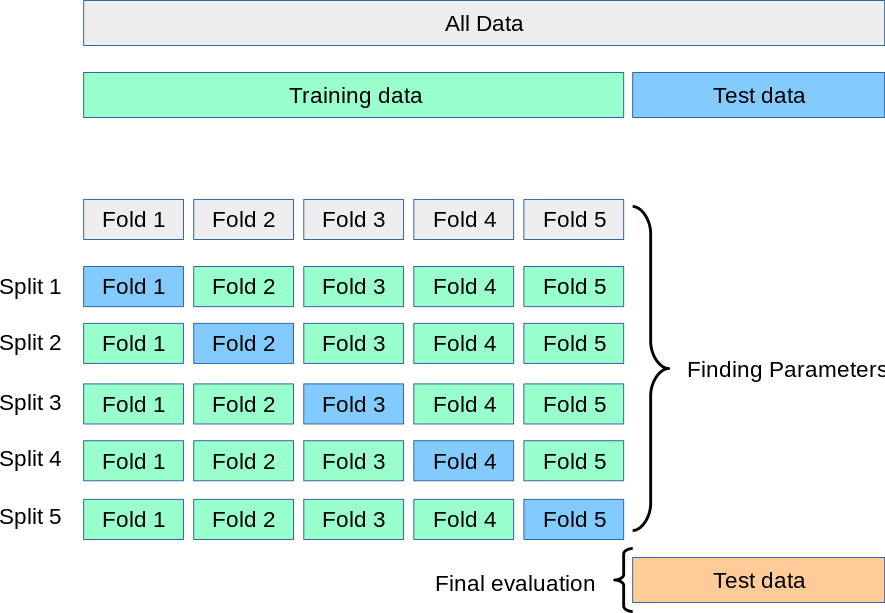

In [ ]:
# Get the best model
best_model = grid_search.best_estimator_

In [ ]:
# Predict on the test set
test_predictions = best_model.predict(X_test)

# Create a DataFrame for the submission
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

# Save the submission to a CSV file
submission.to_csv('titanic_submission.csv', index=False)

# Submitting Predictions on Kaggle
To submit your predictions:
0. Download the titanic_submission.csv to your local.
1. Go to the Titanic competition page.
2. Upload the titanic_submission.csv file that you created.
3. Click on "Submit" to see your score on the leaderboard.